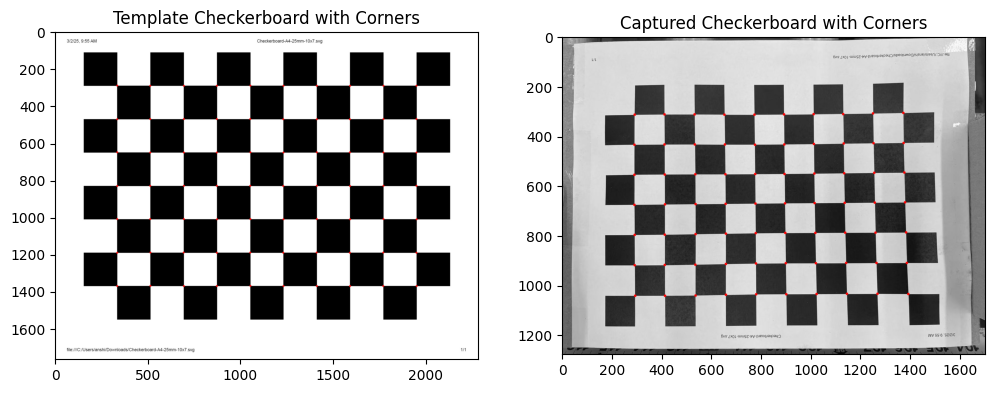

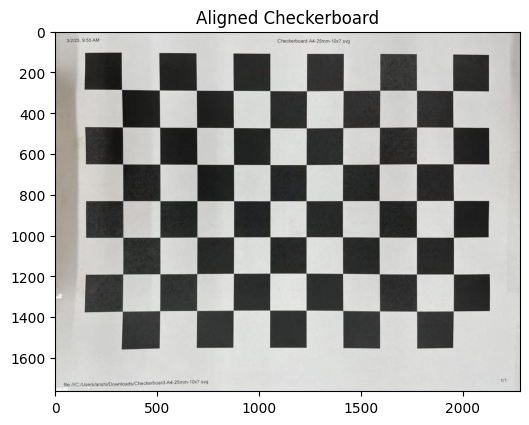

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def find_checkerboard_corners(image_path, pattern_size):
    """ Detects checkerboard corners in an image and returns them. """
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    found, corners = cv2.findChessboardCorners(image, pattern_size, None)

    if found:
        return corners.reshape(-1, 2), image
    else:
        raise ValueError(f"Checkerboard not found in {image_path}")

def draw_checkerboard_corners(image, corners):
    """ Draws detected checkerboard corners on an image. """
    image_with_corners = cv2.cvtColor(image, cv2.COLOR_GRAY2BGR)
    for point in corners:
        cv2.circle(image_with_corners, tuple(int(x) for x in point), 5, (0, 0, 255), -1)
    return image_with_corners

def compute_homography(template_corners, captured_corners):
    """ Computes the homography matrix from template to captured image. """
    H, _ = cv2.findHomography(captured_corners, template_corners, cv2.RANSAC, 5.0)
    return H

def align_captured_image(captured_img_path, H, output_size):
    """ Warps the captured image to align with the template checkerboard. """
    captured_img = cv2.imread(captured_img_path)
    aligned_img = cv2.warpPerspective(captured_img, H, output_size)
    return aligned_img

def visualize_matches(template_img, captured_img, template_corners, captured_corners):
    """ Visualizes corresponding keypoints between template and captured images. """
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    
    # Draw detected checkerboard corners
    template_with_corners = draw_checkerboard_corners(template_img, template_corners)
    captured_with_corners = draw_checkerboard_corners(captured_img, captured_corners)

    # Show template and captured images with detected points
    axes[0].imshow(cv2.cvtColor(template_with_corners, cv2.COLOR_BGR2RGB))
    axes[0].set_title("Template Checkerboard with Corners")

    axes[1].imshow(cv2.cvtColor(captured_with_corners, cv2.COLOR_BGR2RGB))
    axes[1].set_title("Captured Checkerboard with Corners")

    plt.show()

# Define the checkerboard pattern size (number of inner corners per row and column)
pattern_size = (10, 7)  # Adjust based on your checkerboard

# Paths to images
template_path = "template address"
captured_path = "image file"

# Detect checkerboard corners
template_corners, template_img = find_checkerboard_corners(template_path, pattern_size)
captured_corners, captured_img = find_checkerboard_corners(captured_path, pattern_size)

# Visualize detected checkerboard corners
visualize_matches(template_img, captured_img, template_corners, captured_corners)

# Compute homography based on the checkerboard regions
H = compute_homography(template_corners, captured_corners)

# Align captured image to the template
output_size = (template_img.shape[1], template_img.shape[0])
aligned_image = align_captured_image(captured_path, H, output_size)

# Save and visualize aligned image
cv2.imwrite("aligned_checkerboard.jpg", aligned_image)

# Show the alignment result
plt.figure(figsize=(6, 6))
plt.imshow(cv2.cvtColor(aligned_image, cv2.COLOR_BGR2RGB))
plt.title("Aligned Checkerboard")
plt.show()


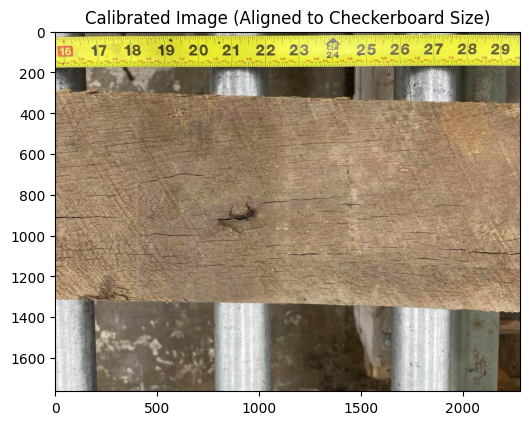

In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def apply_homography_to_fit_checkerboard(image_path, H, template_size):
    """ Applies the homography transformation to an image and resizes it to match the template checkerboard dimensions. """
    image = cv2.imread(image_path)
    transformed_img = cv2.warpPerspective(image, H, template_size)
    return transformed_img

# Path to the new image captured in the same conditions (without a checkerboard)
new_image_path = "calibrated image"

# Define the template checkerboard dimensions (width, height)
template_size = (template_img.shape[1], template_img.shape[0])  # (width, height)

# Apply homography and fit the image to the checkerboard size
calibrated_image = apply_homography_to_fit_checkerboard(new_image_path, H, template_size)

# Save and visualize the calibrated image
cv2.imwrite("calibrated image", calibrated_image)

# Display the calibrated image
plt.figure(figsize=(6, 6))
plt.imshow(cv2.cvtColor(calibrated_image, cv2.COLOR_BGR2RGB))
plt.title("Calibrated Image (Aligned to Checkerboard Size)")
plt.show()



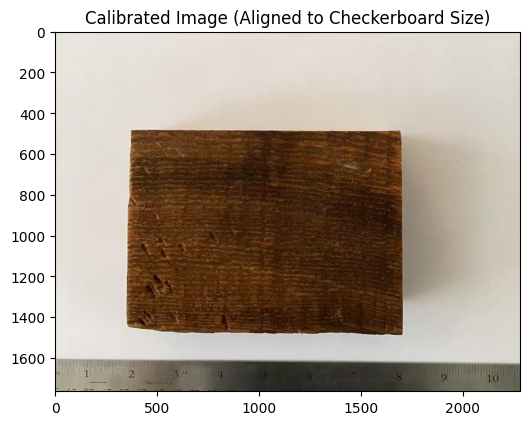

In [21]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def apply_homography_to_fit_checkerboard(image_path, H, template_size):
    """ Applies the homography transformation to an image and resizes it to match the template checkerboard dimensions. """
    image = cv2.imread(image_path)
    transformed_img = cv2.warpPerspective(image, H, template_size)
    return transformed_img

# Path to the new image captured in the same conditions (without a checkerboard)
new_image_path = "calibrated"

# Define the template checkerboard dimensions (width, height)
template_size = (template_img.shape[1], template_img.shape[0])  # (width, height)

# Apply homography and fit the image to the checkerboard size
calibrated_image = apply_homography_to_fit_checkerboard(new_image_path, H, template_size)

# Save and visualize the calibrated image
cv2.imwrite("calibrated_image.jpg", calibrated_image)

# Display the calibrated image
plt.figure(figsize=(6, 6))
plt.imshow(cv2.cvtColor(calibrated_image, cv2.COLOR_BGR2RGB))
plt.title("Calibrated Image (Aligned to Checkerboard Size)")
plt.show()



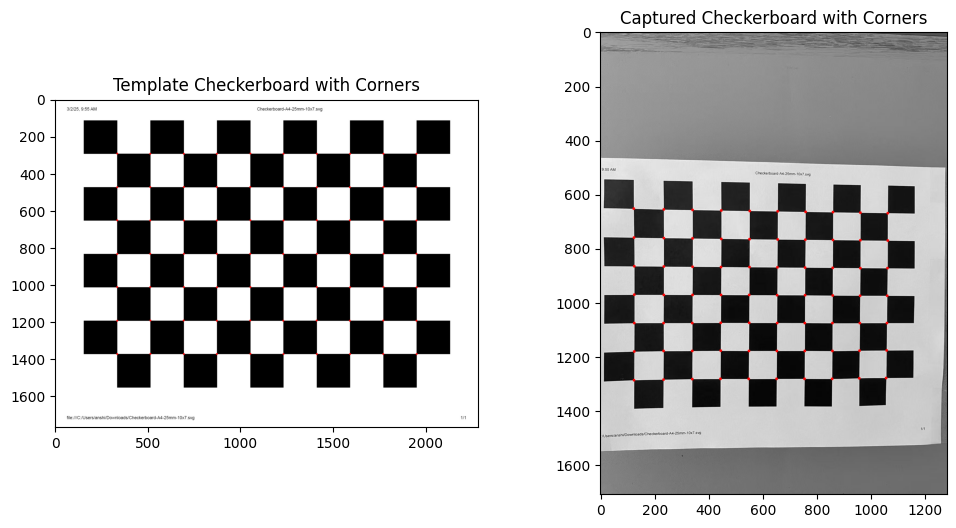

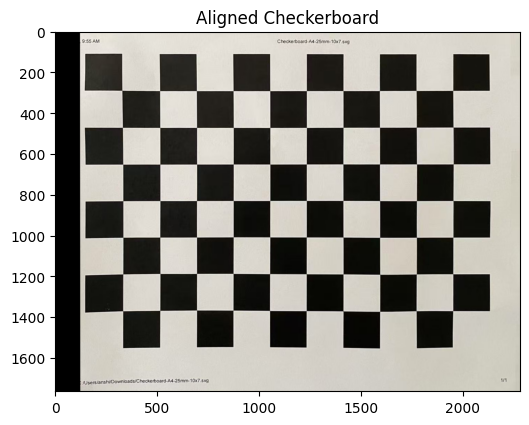

In [22]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def find_checkerboard_corners(image_path, pattern_size):
    """ Detects checkerboard corners in an image and returns them. """
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    found, corners = cv2.findChessboardCorners(image, pattern_size, None)

    if found:
        return corners.reshape(-1, 2), image
    else:
        raise ValueError(f"Checkerboard not found in {image_path}")

def draw_checkerboard_corners(image, corners):
    """ Draws detected checkerboard corners on an image. """
    image_with_corners = cv2.cvtColor(image, cv2.COLOR_GRAY2BGR)
    for point in corners:
        cv2.circle(image_with_corners, tuple(int(x) for x in point), 5, (0, 0, 255), -1)
    return image_with_corners

def compute_homography(template_corners, captured_corners):
    """ Computes the homography matrix from template to captured image. """
    H, _ = cv2.findHomography(captured_corners, template_corners, cv2.RANSAC, 5.0)
    return H

def align_captured_image(captured_img_path, H, output_size):
    """ Warps the captured image to align with the template checkerboard. """
    captured_img = cv2.imread(captured_img_path)
    aligned_img = cv2.warpPerspective(captured_img, H, output_size)
    return aligned_img

def visualize_matches(template_img, captured_img, template_corners, captured_corners):
    """ Visualizes corresponding keypoints between template and captured images. """
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    
    # Draw detected checkerboard corners
    template_with_corners = draw_checkerboard_corners(template_img, template_corners)
    captured_with_corners = draw_checkerboard_corners(captured_img, captured_corners)

    # Show template and captured images with detected points
    axes[0].imshow(cv2.cvtColor(template_with_corners, cv2.COLOR_BGR2RGB))
    axes[0].set_title("Template Checkerboard with Corners")

    axes[1].imshow(cv2.cvtColor(captured_with_corners, cv2.COLOR_BGR2RGB))
    axes[1].set_title("Captured Checkerboard with Corners")

    plt.show()

# Define the checkerboard pattern size (number of inner corners per row and column)
pattern_size = (10, 7)  # Adjust based on your checkerboard

# Paths to images
template_path = "template"
captured_path = "captured"

# Detect checkerboard corners
template_corners, template_img = find_checkerboard_corners(template_path, pattern_size)
captured_corners, captured_img = find_checkerboard_corners(captured_path, pattern_size)

# Visualize detected checkerboard corners
visualize_matches(template_img, captured_img, template_corners, captured_corners)

# Compute homography based on the checkerboard regions
H = compute_homography(template_corners, captured_corners)

# Align captured image to the template
output_size = (template_img.shape[1], template_img.shape[0])
aligned_image = align_captured_image(captured_path, H, output_size)

# Save and visualize aligned image
cv2.imwrite("aligned_checkerboard.jpg", aligned_image)

# Show the alignment result
plt.figure(figsize=(6, 6))
plt.imshow(cv2.cvtColor(aligned_image, cv2.COLOR_BGR2RGB))
plt.title("Aligned Checkerboard")
plt.show()


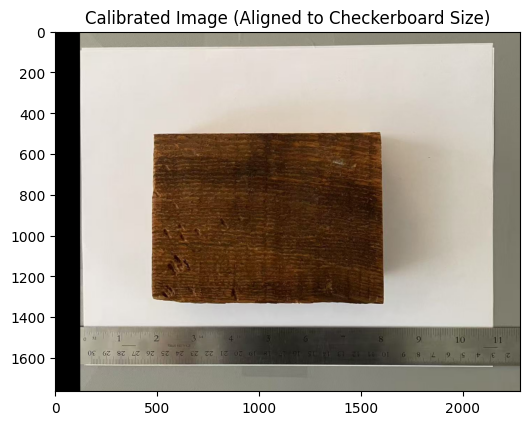

In [23]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def apply_homography_to_fit_checkerboard(image_path, H, template_size):
    """ Applies the homography transformation to an image and resizes it to match the template checkerboard dimensions. """
    image = cv2.imread(image_path)
    transformed_img = cv2.warpPerspective(image, H, template_size)
    return transformed_img

# Path to the new image captured in the same conditions (without a checkerboard)
new_image_path = "calibrated"

# Define the template checkerboard dimensions (width, height)
template_size = (template_img.shape[1], template_img.shape[0])  # (width, height)

# Apply homography and fit the image to the checkerboard size
calibrated_image = apply_homography_to_fit_checkerboard(new_image_path, H, template_size)

# Save and visualize the calibrated image
cv2.imwrite("calibrated_image.jpg", calibrated_image)

# Display the calibrated image
plt.figure(figsize=(6, 6))
plt.imshow(cv2.cvtColor(calibrated_image, cv2.COLOR_BGR2RGB))
plt.title("Calibrated Image (Aligned to Checkerboard Size)")
plt.show()

